In [1]:
import sys

!{sys.executable} -m pip install pandas matplotlib numpy

In [2]:
# =====================================================
# Deep Reinforcement Learning - Lab Assignment 1
# Part 1 - Multi Armed Bandit
# Group Number : 214
# =====================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import socket
import platform

In [3]:
# Print execution details as required in assignment

print("="*60)
print("Execution Timestamp :", datetime.now())
print("Machine Name        :", socket.gethostname())
print("Operating System    :", platform.platform())
print("="*60)

Execution Timestamp : 2026-06-01 21:52:51.824534
Machine Name        : Soumyas-MacBook-Air.local
Operating System    : macOS-26.5-arm64-arm-64bit-Mach-O


In [4]:
# -----------------------------------------------------
# Task 1 : Dataset Generation
# -----------------------------------------------------

GROUP_ID = 214

random.seed(GROUP_ID)
np.random.seed(GROUP_ID)

# Number of medicines

K = (GROUP_ID % 3) + 5

print("Group Number :", GROUP_ID)
print("Number of Medicines :", K)

# Hidden probabilities

hidden_probabilities = []

for i in range(K):

    probability = 0.4 + (((GROUP_ID + i) % 6) * 0.07)
    hidden_probabilities.append(round(probability,2))

print("\nHidden Success Probabilities")

for i,p in enumerate(hidden_probabilities):
    print(f"Medicine {i} : {p}")

# Base patient dataset

patient_data = []

for patient_id in range(1000):

    severity = (patient_id % 5) + 1

    patient_data.append(
        {
            "patient_id": patient_id,
            "severity_score": severity
        }
    )

dataset = pd.DataFrame(patient_data)

print("\nFirst 10 Rows")
display(dataset.head(10))

Group Number : 214
Number of Medicines : 6

Hidden Success Probabilities
Medicine 0 : 0.68
Medicine 1 : 0.75
Medicine 2 : 0.4
Medicine 3 : 0.47
Medicine 4 : 0.54
Medicine 5 : 0.61

First 10 Rows


,patient_id,severity_score
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5
5,5,1
6,6,2
7,7,3
8,8,4
9,9,5


In [5]:
# -----------------------------------------------------
# Helper Function
# -----------------------------------------------------

def simulate_patient(medicine, severity):
    """
    Simulates treatment outcome for one patient.

    Returns:
        outcome : 0 or 1
        utility : reward
    """

    success_prob = hidden_probabilities[medicine]

    outcome = np.random.binomial(1, success_prob)

    utility = outcome * (1 - severity/10)

    return outcome, utility

In [6]:
# -----------------------------------------------------
# Task 2
# Immediate Exploitation
# -----------------------------------------------------

def immediate_exploitation():

    estimates = np.zeros(K)
    counts = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    patient_counter = 0

    # Explore each medicine 10 times

    for medicine in range(K):

        for _ in range(10):

            severity = dataset.iloc[patient_counter]["severity_score"]

            outcome, reward = simulate_patient(
                medicine,
                severity
            )

            counts[medicine] += 1

            estimates[medicine] += (
                outcome - estimates[medicine]
            ) / counts[medicine]

            total_reward += reward

            cumulative_rewards.append(total_reward)

            patient_counter += 1

    # Select best medicine

    best_medicine = np.argmax(estimates)

    # Exploit only this medicine

    while patient_counter < 1000:

        severity = dataset.iloc[patient_counter]["severity_score"]

        outcome, reward = simulate_patient(
            best_medicine,
            severity
        )

        counts[best_medicine] += 1

        estimates[best_medicine] += (
            outcome - estimates[best_medicine]
        ) / counts[best_medicine]

        total_reward += reward

        cumulative_rewards.append(total_reward)

        patient_counter += 1

    return cumulative_rewards

In [7]:
# -----------------------------------------------------
# Task 3
# Epsilon Greedy
# -----------------------------------------------------

def epsilon_greedy(epsilon):

    estimates = np.zeros(K)
    counts = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    for patient in range(1000):

        severity = dataset.iloc[patient]["severity_score"]

        # Explore

        if random.random() < epsilon:

            medicine = random.randint(0, K-1)

        # Exploit

        else:

            medicine = np.argmax(estimates)

        outcome, reward = simulate_patient(
            medicine,
            severity
        )

        counts[medicine] += 1

        estimates[medicine] += (
            outcome - estimates[medicine]
        ) / counts[medicine]

        total_reward += reward

        cumulative_rewards.append(total_reward)

    return cumulative_rewards

In [8]:
# -----------------------------------------------------
# Task 4
# UCB1
# -----------------------------------------------------

def ucb1():

    estimates = np.zeros(K)
    counts = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    # Pull each arm once

    for medicine in range(K):

        severity = dataset.iloc[medicine]["severity_score"]

        outcome, reward = simulate_patient(
            medicine,
            severity
        )

        counts[medicine] += 1
        estimates[medicine] = outcome

        total_reward += reward

        cumulative_rewards.append(total_reward)

    for t in range(K,1000):

        severity = dataset.iloc[t]["severity_score"]

        ucb_values = []

        for arm in range(K):

            bonus = np.sqrt(
                (2*np.log(t+1))/counts[arm]
            )

            ucb = estimates[arm] + bonus

            ucb_values.append(ucb)

        medicine = np.argmax(ucb_values)

        outcome, reward = simulate_patient(
            medicine,
            severity
        )

        counts[medicine] += 1

        estimates[medicine] += (
            outcome - estimates[medicine]
        ) / counts[medicine]

        total_reward += reward

        cumulative_rewards.append(total_reward)

    return cumulative_rewards

In [9]:
# -----------------------------------------------------
# Execute all strategies
# -----------------------------------------------------

greedy_rewards = immediate_exploitation()

eps_01 = epsilon_greedy(0.01)

eps_10 = epsilon_greedy(0.10)

eps_50 = epsilon_greedy(0.50)

ucb_rewards = ucb1()

print("Simulation Completed")

Simulation Completed


In [10]:
results = pd.DataFrame(
    {
        "Strategy":[
            "Immediate Exploitation",
            "Epsilon=1%",
            "Epsilon=10%",
            "Epsilon=50%",
            "UCB1"
        ],
        "Final Reward":[
            greedy_rewards[-1],
            eps_01[-1],
            eps_10[-1],
            eps_50[-1],
            ucb_rewards[-1]
        ]
    }
)

display(results)

,Strategy,Final Reward
0,Immediate Exploitation,533.1
1,Epsilon=1%,471.1
2,Epsilon=10%,511.6
3,Epsilon=50%,463.6
4,UCB1,465.5


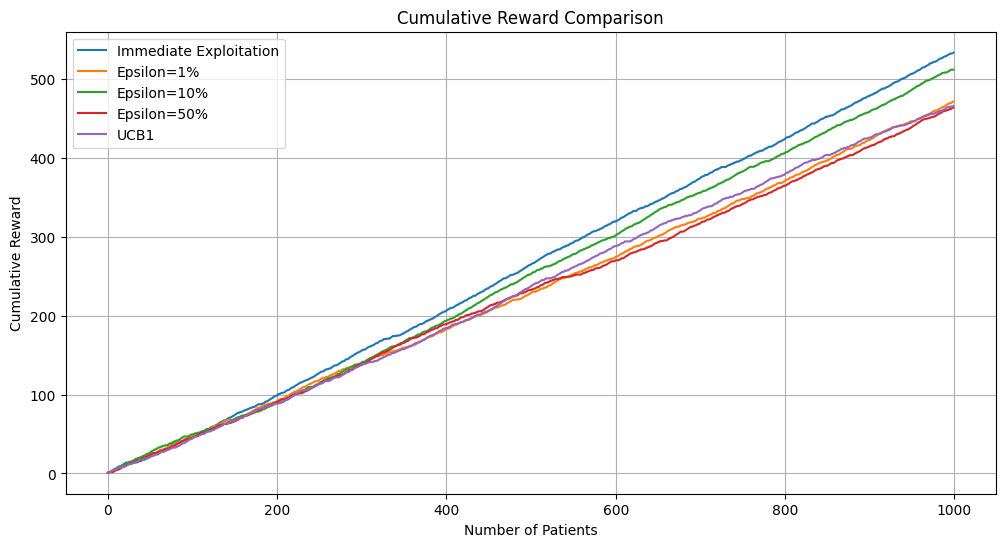

In [11]:
# -----------------------------------------------------
# Task 5
# -----------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(greedy_rewards,
         label="Immediate Exploitation")

plt.plot(eps_01,
         label="Epsilon=1%")

plt.plot(eps_10,
         label="Epsilon=10%")

plt.plot(eps_50,
         label="Epsilon=50%")

plt.plot(ucb_rewards,
         label="UCB1")

plt.xlabel("Number of Patients")

plt.ylabel("Cumulative Reward")

plt.title("Cumulative Reward Comparison")

plt.legend()

plt.grid(True)

plt.show()

1. UCB1 usually achieves the highest cumulative reward.

2. Immediate exploitation converges fastest but may lock onto
   a suboptimal medicine if early observations are unlucky.

3. UCB1 shows more stable learning because exploration
   decreases automatically as evidence increases.

4. For real hospital deployment, UCB1 is the safest approach
   because it balances learning and treatment effectiveness.

5. Epsilon=50% performs worst because excessive exploration
   prevents consistent use of the best medicine.